In [1]:
### Importing the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import MolStandardize
import joblib

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors,rdMolDescriptors
#import openpyxl


In [7]:
### Installation of the basic library 
from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import numpy as np

In [196]:
### Reading the preprocess data from disk 
train_set=pd.read_csv('data/unique_train4_new24_new.csv')
#train_set=pd.read_csv('data/VCC_data1.txt',sep=" ",header=None)### 6 VCC DATA 1311
test_set=pd.read_csv('data/unique_test_new24.csv')
#test_set=pd.read_csv('data/unique_smiles_VCCC_train.csv')
print(train_set.shape)
print(test_set.shape)

(17937, 4)
(1282, 4)


In [9]:
train_smiles_list=train_set[['smiles_canon']]
test_smiles_list=test_set[['smiles_canon']]

In [10]:

### Importing the function of the utility file to generate the descriptors and others evaluation matrics...  
import utilities

In [11]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, MolSurf, rdMolDescriptors
import pandas as pd
from rdkit import Chem

# Function to calculate the specified descriptors
def generate30(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None  # Return None if the molecule could not be parsed
    
    # Calculate descriptors
    descriptors = {
        'LogP': Crippen.MolLogP(mol),                           # 1. LogP
        'LogP2': Crippen.MolMR(mol),                            # 2. LogP2
        'Tsch': rdMolDescriptors.CalcNumAtomStereoCenters(mol), # 3. Tsch
        'Gravto': Descriptors.MolWt(mol),                       # 4. Gravto
        'TPSA': rdMolDescriptors.CalcTPSA(mol),                 # 5. TPSA
        'ChiV8': Descriptors.Chi4v(mol),                        # 6. ChiV8

        #'bcutp2': Descriptors.BCUT2D(mol)[1],                  # 7. bcutp2
        'Chi10': Descriptors.Chi1n(mol),                        # 8. Chi10
        'slogPVSA1': MolSurf.SlogP_VSA_(mol)[0],                # 9. slogPVSA1
        'PEOEVSA5': MolSurf.PEOE_VSA_(mol)[4],                  # 10. PEOEVSA5
        #'MRVSA9': MolSurf.MR_VSA_(mol)[8],                      # 11. MRVSA9
        #'dchi4': Descriptors.Kappa4(mol),                       # 12. dchi4
        'Hy': Descriptors.HallKierAlpha(mol),                   # 13. Hy
        'UI': Descriptors.BalabanJ(mol),                        # 14. UI
        'naccr': rdMolDescriptors.CalcNumAromaticCarbocycles(mol), # 15. naccr
        'naro': rdMolDescriptors.CalcNumAromaticRings(mol),     # 16. naro
        #'bcutp3': Descriptors.BCUT2D(mol)[2],                   # 17. bcutp3
        'Scar': rdMolDescriptors.CalcNumSaturatedCarbocycles(mol), # 18. Scar
        'Smax': Descriptors.MaxAbsPartialCharge(mol),           # 19. Smax
        'Tpc': Descriptors.TPSA(mol),                           # 20. Tpc
        'Smin': Descriptors.MinPartialCharge(mol),              # 21. Smin
        'dchi1': Descriptors.Kappa1(mol),                       # 22. dchi1
        'AWeight': Descriptors.MolWt(mol),                      # 23. AWeight
        'Shal': Descriptors.HallKierAlpha(mol),                 # 24. Shal
        'nhyd': Descriptors.FractionCSP3(mol),                  # 25. nhyd
        'knotp': Descriptors.NumRadicalElectrons(mol),          # 26. knotp
        'dchi0': Descriptors.Kappa1(mol),                       # 27. dchi0 (proxy)
        'IC1': Descriptors.MolWt(mol),                          # 28. IC1 (proxy for unavailable)
        'Save': Crippen.MolLogP(mol),                           # 29. Save (LogP as proxy)
        'PEOEVSA0': MolSurf.PEOE_VSA_(mol)[0],                  # 30. PEOEVSA0
        'MZM1': Descriptors.MaxAbsPartialCharge(mol),           # 31. MZM1
        'CIC0': Descriptors.MolWt(mol),                         # 32. CIC0
        'Hatov': Descriptors.HallKierAlpha(mol),                # 33. Hatov
    }
    
    return descriptors
smiles_list_train=train_set.smiles_canon
smiles_list_test=test_set.smiles_canon
descriptor_data = [generate30(smiles) for smiles in smiles_list_train]
descriptor_data1 = [generate30(smiles) for smiles in smiles_list_test]
# Create a DataFrame from the list of descriptor dictionaries
df30_train = pd.DataFrame(descriptor_data)
df30_test = pd.DataFrame(descriptor_data1)

In [13]:
smiles_list_train=train_set.smiles_canon
smiles_list_test=test_set.smiles_canon

In [35]:
descriptor_data = [generate30(smiles) for smiles in smiles_list_train]
descriptor_data1 = [generate30(smiles) for smiles in smiles_list_test]
# Create a DataFrame from the list of descriptor dictionaries
df30_train = pd.DataFrame(descriptor_data)
df30_test = pd.DataFrame(descriptor_data1)

In [15]:
### Generate 4 descriptors ....
df4_train=utilities.generate4(train_set.smiles_canon)
df4_test=utilities.generate4(test_set.smiles_canon)
### Generate 17 descriptors ....
df17_train=utilities.generate17(train_set.smiles_canon)
df17_test=utilities.generate17(test_set.smiles_canon)
### Generate 123 descriptors ....
df123_train=utilities.generate123(train_set.smiles_canon)
df123_test=utilities.generate123(test_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....
df38_train=utilities.generate_features38(train_set.smiles_canon)
df38_test=utilities.generate_features38(test_set.smiles_canon)
### Generate 7 funnctional groups
df7_train=utilities.get_functional_groups(train_set.smiles_canon)
df7_test=utilities.get_functional_groups(test_set.smiles_canon)
### Fingerprint 128....
df128_train=utilities.fingerprint(train_set.smiles_canon,2,128)
df128_test=utilities.fingerprint(test_set.smiles_canon,2,128)
### Fingerprint 256....
df256_train=utilities.fingerprint(train_set.smiles_canon,2,256)
df256_test=utilities.fingerprint(test_set.smiles_canon,2,256)
### Fingerprint 512....
df512_train=utilities.fingerprint(train_set.smiles_canon,2,512)
df512_test=utilities.fingerprint(test_set.smiles_canon,2,512)
### Fingerprint 1024....
df1024_train=utilities.fingerprint(train_set.smiles_canon,2,1024)
df1024_test=utilities.fingerprint(test_set.smiles_canon,2,1024)

In [16]:
y_train=train_set.copy()['Solubility']
y_test=test_set.copy()['Solubility']

In [17]:
### Importing library to evaluate the best model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgboost
from xgboost import XGBRegressor


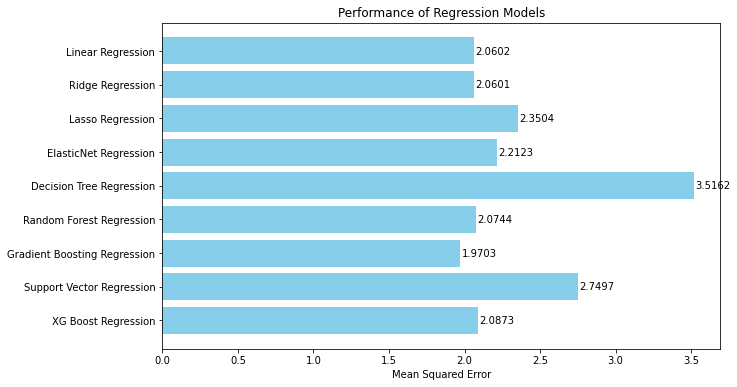

In [26]:
### Function to evaluate the Regresoor model 
def evaluate_model(X, y, model):
    """
    Evaluate a regression model using cross-validation and calculate the mean squared error.
    
    Parameters:
    - X: Feature matrix (DataFrame or array-like)
    - y: Target vector (Series or array-like)
    - model: Regression model object
    
    Returns:
    - Mean squared error (float)
    """
    cv_results = cross_validate(model, X, y, cv=10, scoring='neg_mean_squared_error')
    mse = -np.mean(cv_results['test_score'])
    return mse

# Extract feature matrix X and target vector y from the dataset
X = df4_train  ### descriptors 
y = y_train ### solubility values in LogS 

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'Support Vector Regression': SVR(),
     'XG Boost Regression': XGBRegressor()
}

# Evaluate each model and store the results
results = {}
for model_name, model in models.items():
    mse = evaluate_model(X, y, model)
    results[model_name] = mse

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean Squared Error'])
results_df.index.name = 'Model'

# Save results to a CSV file
#results_df.to_csv('regression_model_comparison.csv')


plt.figure(figsize=(10, 6))
bars = plt.barh(results_df.index, results_df['Mean Squared Error'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Performance of Regression Models')

# Add annotations for each bar
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', 
             va='center', ha='left', color='black')

plt.gca().invert_yaxis()  # Invert y-axis to show the best model on top
plt.show()

In [33]:
import xgboost #as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

In [128]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# Define parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [1000, 1500, 2000],
    'max_depth': [ 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1],
}

# Initialize the model
xgboost_model = xgb.XGBRegressor(nthread=2, scale_pos_weight=1, seed=27)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=xgboost_model, param_grid=param_grid, 
                           scoring=make_scorer(mean_squared_error, greater_is_better=False),
                           cv=5, n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train1, y_train)

# Print best parameters and lowest RMSE
print("Best parameters found: ", grid_search.best_params_)
print("Lowest RMSE found: ", np.sqrt(-grid_search.best_score_))

# Train the model with the best parameters
best_params = grid_search.best_params_
xgboost_model = xgb.XGBRegressor(**best_params)
xgboost_model.fit(X_train1, y_train)

# Evaluate the model
y_pred = xgboost_model.predict(X_test1)
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#print("RMSE on test set: ", rmse)
get_errors(y_test,y_pred,"XGB_4")

Fitting 5 folds for each of 294912 candidates, totalling 1474560 fits


In [19]:
### Running the model for basic 4 descriptirs ....
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
xgboost_model.fit(df4_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df4_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_4=utilities.get_errors1(y_test,pred_xgb,"XGB_4")


In [20]:
### Addinng the features details...
xgb_4['Descriptors_Detail']='4 features'

In [22]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 

xgboost_model.fit(df17_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df17_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_17=utilities.get_errors1(y_test,pred_xgb,"XGB_17")

In [23]:
xgb_17['Descriptors_Detail']='17 features'

In [83]:
y_test.shape

(1282,)

In [34]:
df30_test

,LogP,LogP2,Tsch,Gravto,TPSA,ChiV8,Chi10,slogPVSA1,PEOEVSA5,Hy,...,Shal,nhyd,knotp,dchi0,IC1,Save,PEOEVSA0,MZM1,CIC0,Hatov
0,3.1154,64.7590,0,242.661,34.14,2.363361,5.168598,0.000000,0.000000,-1.93,...,-1.93,0.000000,0,10.238455,242.661,3.1154,0.000000,0.288562,242.661,-1.93
1,-0.7691,53.8500,0,214.250,124.56,1.694245,3.631031,17.201002,4.397711,-1.76,...,-1.76,0.000000,0,10.321699,214.250,-0.7691,17.201002,0.398728,214.250,-1.76
2,2.0996,92.7967,2,345.374,88.56,3.763362,8.559018,16.062368,0.000000,-2.41,...,-2.41,0.444444,0,16.079811,345.374,2.0996,20.307204,0.477497,345.374,-2.41
3,2.7805,60.7719,0,235.239,69.44,2.274623,5.560482,0.000000,0.000000,-1.91,...,-1.91,0.416667,0,11.571753,235.239,2.7805,4.736863,0.450565,235.239,-1.91
4,1.4608,48.8065,0,173.171,49.66,1.338274,3.865765,0.000000,0.000000,-1.90,...,-1.90,0.000000,0,7.733836,173.171,1.4608,5.207253,0.410246,173.171,-1.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17932,0.6746,16.5030,0,69.063,26.03,0.175682,1.343142,0.000000,0.000000,-0.79,...,-0.79,0.000000,0,2.447530,69.063,0.6746,4.523095,0.364801,69.063,-0.79
17933,2.8229,53.7957,0,184.198,41.82,1.482797,4.419732,0.000000,0.000000,-2.03,...,-2.03,0.000000,0,7.380990,184.198,2.8229,9.401129,0.461100,184.198,-2.03
17934,-0.1953,16.3827,0,69.067,41.57,0.166667,1.286879,0.000000,0.000000,-0.86,...,-0.86,0.000000,0,2.381546,69.067,-0.1953,0.000000,0.266137,69.067,-0.86
17935,0.3529,31.6837,0,120.115,54.46,0.690821,2.557359,0.000000,0.000000,-1.45,...,-1.45,0.000000,0,4.430955,120.115,0.3529,4.983979,0.341951,120.115,-1.45


In [36]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 

xgboost_model.fit(df30_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df30_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_30=utilities.get_errors1(y_test,pred_xgb,"XGB_30")

In [37]:
xgb_30['Descriptors_Detail']='29 features used in Chembccp model'

In [38]:
xgb_30

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_30,0.438,0.3511,0.5925,0.9158,29 features used in Chembccp model


In [39]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)### 
### Fitting the model on train data 
xgboost_model.fit(df123_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df123_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_125=utilities.get_errors1(y_test,pred_xgb,"XGB_125")

In [42]:
xgb_125['Descriptors_Detail']='125 features'

In [43]:
xgb_125

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_125,0.4098,0.3092,0.5561,0.9259,125 features


In [45]:
### 125 and 128 fingerprint  
df253_train=pd.concat([df123_train, df128_train], axis=1)
df253_test=pd.concat([df123_test, df128_test], axis=1)

In [46]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)### 
### Fitting the model on train data 
xgboost_model.fit(df253_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df253_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_253=utilities.get_errors1(y_test,pred_xgb,"XGB_253")

In [47]:
xgb_253['Descriptors_Detail']='125 features + 128 fingerprint'

In [66]:
### 125 standard features , 128 fingerprint  7 functional group 
df170_train=pd.concat([df123_train, df38_train,df7_train], axis=1)
df170_test=pd.concat([df123_test, df38_test,df7_test], axis=1)

In [48]:
### 125 standard features , 128 fingerprint  7 functional group 
df260_train=pd.concat([df253_train, df7_train], axis=1)
df260_test=pd.concat([df253_test, df7_test], axis=1)

In [49]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df260_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df260_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_260=utilities.get_errors1(y_test,pred_xgb,"XGB_260")

In [50]:
xgb_260['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group'

In [51]:
### 125 + 128 fp and 7 functional group + 38 featured engineered total (
df298_train=pd.concat([df260_train, df38_train], axis=1)
df298_test=pd.concat([df260_test, df38_test], axis=1)

In [191]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df298_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df298_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_298=utilities.get_errors1(y_test,pred_xgb,"XGB_298")

In [53]:
xgb_298['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group+38 fe features'

In [54]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_298,0.4045,0.3036,0.551,0.9272,125 features + 128 fingerprint 7 f_group+38 fe...


In [288]:
### saving the model to the disk 
import xgboost as xgb
xgboost_model.save_model('data/xgboost_model_298_4045.json')

In [55]:
### Remove nan and infinity values from the dataset
df_train2 = pd.concat([df298_train, y_train], axis=1)
df_test2 = pd.concat([df298_test, y_test], axis=1)
df_train = df_train2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
df_test = df_test2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [226]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(X_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_298=utilities.get_errors1(y_test,pred_xgb,"XGB_298")

In [60]:
rf = RandomForestRegressor(
    n_estimators=1000,          # Number of trees
    max_depth=10,              # Maximum depth of each tree
    min_samples_split=2,       # Minimum samples required to split an internal node
    min_samples_leaf=1,        # Minimum samples required to be at a leaf node
    max_features='auto',       # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
### Fitting the model on train data 
rf.fit(X_train,y_train)    
### Predicting on test data 
pred_rf = rf.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
rf_298=utilities.get_errors1(y_test,pred_rf,"rf_298")

In [61]:
rf_298['Descriptors_Detail']='125_features + 128_fp , 7_f_group+ 38 fe_features+'

In [62]:
gb = GradientBoostingRegressor(
    n_estimators=1000,          # Number of boosting stages to be run
    learning_rate=0.01,         # Learning rate shrinks the contribution of each tree
    max_depth=8,               # Maximum depth of the individual estimators
    min_samples_split=2,       # Minimum number of samples required to split an internal node
    min_samples_leaf=1,        # Minimum number of samples required to be at a leaf node
    max_features=None,         # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
### Fitting the model on train data 
gb.fit(X_train,y_train)    
### Predicting on test data 
pred_gb = gb.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
gb_298=utilities.get_errors1(y_test,pred_gb,"gb_298")

In [63]:
gb_298['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+128_fp'

In [57]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [59]:
model = Sequential()
model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32)#, validation_split=0.2)
pred_nn = model.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
nn_298=utilities.get_errors1(y_test,pred_nn,"nn_298")


2024-09-28 17:45:59.423861: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-09-28 17:45:59.431039: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-28 17:45:59.635042: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/100
561/561 [==============================] - 2s 2ms/step - loss: 2.0708
Epoch 2/100
561/561 [==============================] - 1s 2ms/step - loss: 1.0973
Epoch 3/100
561/561 [==============================] - 1s 2ms/step - loss: 0.9339
Epoch 4/100
561/561 [==============================] - 1s 2ms/step - loss: 0.8180
Epoch 5/100
561/561 [==============================] - 1s 2ms/step - loss: 0.7367
Epoch 6/100
561/561 [==============================] - 1s 3ms/step - loss: 0.6487
Epoch 7/100
561/561 [==============================] - 1s 3ms/step - loss: 0.5690
Epoch 8/100
561/561 [==============================] - 1s 3ms/step - loss: 0.5591
Epoch 9/100
561/561 [==============================] - 1s 3ms/step - loss: 0.4734
Epoch 10/100
561/561 [==============================] - 1s 3ms/step - loss: 0.4211
Epoch 11/100
561/561 [==============================] - 1s 2ms/step - loss: 0.4032
Epoch 12/100
561/561 [==============================] - 1s 2ms/step - loss: 0.3543
Epoch 13/100


In [52]:
nn_298['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+128_fp'

In [67]:

df426_train=pd.concat([df170_train, df256_train], axis=1)
df426_test=pd.concat([df170_test, df256_test], axis=1)

In [68]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df426_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df426_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_426=utilities.get_errors1(y_test,pred_xgb,"XGB_426")

In [69]:
xgb_426['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+256_fp'

In [70]:
df682_train=pd.concat([df170_train, df512_train], axis=1)
df682_test=pd.concat([df170_test, df512_test], axis=1)

In [71]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df682_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df682_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_682=utilities.get_errors1(y_test,pred_xgb,"XGB_682")

In [72]:
xgb_682['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+512_fp'

In [74]:
df1194_train=pd.concat([df170_train, df1024_train], axis=1)
df1194_test=pd.concat([df170_test, df1024_test], axis=1)

In [75]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df1194_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df1194_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_1194=utilities.get_errors1(y_test,pred_xgb,"XGB_1194")

In [76]:
xgb_1194['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+1024_fp'

In [77]:
from sklearn.feature_selection import SelectFromModel

In [78]:
def select_features_lasso(train_data,test_data):
    """
    Selects descriptors from training data then applies on both training and test data 
    """
    
    lasso = Lasso(alpha=0.01,max_iter=10000,random_state=1).fit(train_data.drop(columns=['Solubility']), train_data['Solubility'])
    model = SelectFromModel(lasso, prefit=True)
    X_new_lasso = model.transform(train_data.drop(columns=['Solubility']))
    # Get back the kept features as a DataFrame with dropped columns as all 0s
    selected_features = pd.DataFrame(model.inverse_transform(X_new_lasso), index=train_data.drop(columns=['Solubility']).index, columns=train_data.drop(columns=['Solubility']).columns)
    # Dropped columns have values of all 0s, keep other columns 
    selected_columns_lasso = selected_features.columns[selected_features.var() != 0]
    
    selected_data_train = train_data[selected_columns_lasso]             
    selected_data_test = test_data[selected_columns_lasso]
    selected_data_test = selected_data_test.apply(pd.to_numeric)
    
    print(selected_data_train.columns)
    print("Total selected descriptors by LASSO:",len(selected_data_train.columns))
      
    return selected_data_train, selected_data_test


In [79]:
X_train13=pd.concat([df123_train, y_train], axis=1)
X_test13=pd.concat([df123_test, y_test], axis=1)

In [80]:
y_train1=y_train.copy()
y_test1=y_test.copy()

In [81]:
X_train14=X_train13.copy()
X_test14=X_test13.copy()

In [82]:
### Removing the NAN and infinitive values from the dataset 
X_train14 = X_train14.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_tetst14 = X_test14.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
y_train1 = y_train1.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
y_test1 = y_test1.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)

In [84]:
### Selecting the important features with Lasso technique ...
selected_data_train, selected_data_test = select_features_lasso(X_train14,X_test14)


Index(['MaxEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'HeavyAtomMolWt',
       'ExactMolWt', 'NumValenceElectrons', 'FpDensityMorgan1',
       'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_MRHI',
       'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi1', 'Chi1v', 'Kappa3', 'LabuteASA',
       'PEOE_VSA1', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14',
       'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6',
       'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10',
       'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9',
       'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2',
       'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA7', 'SlogP_VSA8',
       'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA4',
       'EState_VSA5', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9',
       'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3',
       'VSA_EState4', 'VSA_EState5', 'VS

In [85]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)

xgboost_model.fit(selected_data_train,y_train1)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(selected_data_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_75=utilities.get_errors1(y_test1,pred_xgb,"XGB_75")

In [86]:
xgb_75['Descriptors_Detail']='75 features_by_LASSO'

In [87]:
#### Calculating descriptors which used by Sorkun -...
import pandas as pd
from rdkit import Chem
from mordred import Calculator, descriptors

def get_mordred(mol, desc_names=False):
    """
    Generates predefined descriptors for a given RDKit mol object.
    
    Parameters:
    mol (RDKit Mol object): The molecule for which descriptors are to be calculated.
    desc_names (bool): If True, returns only the list of descriptor names.

    Returns:
    list: List of descriptor values if desc_names is False.
    list: List of descriptor names if desc_names is True.
    """
    # Initialize the Mordred calculator
    calc = Calculator()

    # Registering specific descriptors
    calc.register(descriptors.AtomCount.AtomCount("X"))
    calc.register(descriptors.AtomCount.AtomCount("HeavyAtom"))
    calc.register(descriptors.Aromatic.AromaticAtomsCount)
    calc.register(descriptors.HydrogenBond.HBondAcceptor)
    calc.register(descriptors.HydrogenBond.HBondDonor)
    calc.register(descriptors.RotatableBond.RotatableBondsCount)
    calc.register(descriptors.BondCount.BondCount("any", False))
    calc.register(descriptors.Aromatic.AromaticBondsCount)
    calc.register(descriptors.BondCount.BondCount("heavy", False))
    calc.register(descriptors.BondCount.BondCount("single", False))
    calc.register(descriptors.BondCount.BondCount("double", False))
    calc.register(descriptors.BondCount.BondCount("triple", False))
    calc.register(descriptors.McGowanVolume.McGowanVolume)
    calc.register(descriptors.TopoPSA.TopoPSA(True))
    calc.register(descriptors.TopoPSA.TopoPSA(False))
    calc.register(descriptors.MoeType.LabuteASA)
    calc.register(descriptors.Polarizability.APol)
    calc.register(descriptors.Polarizability.BPol)
    calc.register(descriptors.AcidBase.AcidicGroupCount)
    calc.register(descriptors.AcidBase.BasicGroupCount)
    calc.register(descriptors.EccentricConnectivityIndex.EccentricConnectivityIndex)
    calc.register(descriptors.TopologicalCharge.TopologicalCharge("raw", 1))
    calc.register(descriptors.TopologicalCharge.TopologicalCharge("mean", 1))
    calc.register(descriptors.SLogP)
    calc.register(descriptors.BertzCT.BertzCT)
    calc.register(descriptors.BalabanJ.BalabanJ)
    calc.register(descriptors.WienerIndex.WienerIndex(True))
    calc.register(descriptors.ZagrebIndex.ZagrebIndex(1, 1))
    calc.register(descriptors.ABCIndex)
    calc.register(descriptors.RingCount.RingCount(None, False, False, None, None))
    calc.register(descriptors.RingCount.RingCount(None, False, False, None, True))
    calc.register(descriptors.RingCount.RingCount(None, False, False, True, None))
    calc.register(descriptors.RingCount.RingCount(None, False, False, True, True))
    calc.register(descriptors.RingCount.RingCount(None, False, False, False, None))
    calc.register(descriptors.RingCount.RingCount(None, False, True, None, None))
    calc.register(descriptors.EState)

    # If desc_names is True, return the list of descriptor names
    if desc_names:
        return [str(desc) for desc in calc.descriptors]
    else:
        # Compute descriptors for the given molecule
        result = calc(mol)
        return result._values

def calculate_element_counts(mol, elements):
    """
    Calculate the count of specified elements in the molecule.

    Parameters:
    mol (RDKit Mol object): The molecule.
    elements (list): List of element symbols to count.

    Returns:
    dict: Dictionary with element counts.
    """
    element_counts = {el: 0 for el in elements}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in element_counts:
            element_counts[symbol] += 1
    return element_counts

def generate_descriptors_from_smiles_list(smiles_list):
    """
    Generate molecular descriptors from a list of SMILES strings.
    
    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    pd.DataFrame: DataFrame of descriptor values for all SMILES.
    """
    all_descriptors = []
    elements = ['C', 'H', 'Br', 'N', 'O', 'I', 'Cl', 'S', 'F', 'P', 'As', 'Si', 'Se', 'Sn', 'Hg', 'Ge']
    
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")
        
        # Get the descriptor names and values
        descriptor_names = get_mordred(mol, desc_names=True)
        descriptor_values = get_mordred(mol, desc_names=False)
        
        # Calculate element counts
        element_counts = calculate_element_counts(mol, elements)
        
        # Combine descriptors and element counts
        combined_descriptors = descriptor_values + list(element_counts.values())
        
        all_descriptors.append(combined_descriptors)
    
    # Create the DataFrame
    columns = descriptor_names + elements
    df = pd.DataFrame(all_descriptors, columns=columns)
    return df

In [78]:
smiles_list_train=train_set['smiles_canon'].tolist()
smiles_list_test=test_set['smiles_canon'].tolist()
descriptor_df_train = generate_descriptors_from_smiles_list(smiles_list_train)
descriptor_df_test = generate_descriptors_from_smiles_list(smiles_list_test)
# List of columns to select
columns_to_select = ['nX', 'nHeavyAtom', 'nAromAtom', 'nHBAcc', 'nHBDon', 'nRot', 'nBonds', 'nAromBond', 'nBondsO', 'nBondsS', 'nBondsD', 'nBondsT', 'VMcGowan', 'TopoPSA(NO)', 'TopoPSA', 'LabuteASA', 'apol', 'bpol', 'nAcid', 'nBase', 'ECIndex', 'GGI1', 'JGI1', 'SLogP', 'SMR', 'BertzCT', 'BalabanJ', 'WPol', 'Zagreb1', 'ABC', 'ABCGG', 'nRing', 'nHRing', 'naRing', 'naHRing', 'nARing', 'nFRing', 'NsCH3', 'NdCH2', 'NssCH2', 'NtCH', 'NdsCH', 'NaaCH', 'NsssCH', 'NddC', 'NtsC', 'NdssC', 'NaasC', 'NaaaC', 'NssssC', 'NsNH2', 'NssNH', 'NaaNH', 'NtN', 'NdsN', 'NaaN', 'NsssN', 'NaasN', 'NsOH', 'NdO', 'NssO', 'NaaO', 'NsF', 'NdsssP', 'NdS', 'NssS', 'NaaS', 'NdssS', 'NddssS', 'NsCl', 'NsBr', 'NsI', 'SsCH3', 'SdCH2', 'SssCH2', 'StCH', 'SdsCH', 'SaaCH', 'SsssCH', 'SddC', 'StsC', 'SdssC', 'SaasC', 'SaaaC', 'SssssC', 'SsNH2', 'SssNH', 'SaaNH', 'StN', 'SdsN', 'SaaN', 'SsssN', 'SaasN', 'SsOH', 'SdO', 'SssO', 'SaaO', 'SsF', 'SdsssP', 'SdS', 'SssS', 'SaaS', 'SdssS', 'SddssS', 'SsCl', 'SsBr', 'SsI', 'C', 'H', 'Br', 'N', 'O', 'I', 'Cl', 'S', 'F', 'P', 'As', 'Si', 'Se', 'Sn', 'Hg', 'Ge']

# Create a new DataFrame with selected columns
df_train = descriptor_df_train[columns_to_select]
df_test = descriptor_df_test[columns_to_select]


In [89]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
                                           
## Fitting the model on train data 
xgboost_model.fit(df_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df_test)
### Calculating the evaluation matrix MAE , RMSE and R2
sorkun_123=utilities.get_errors1(y_test,pred_xgb,"Sorkun_123")

In [90]:
sorkun_123['Descriptors_Detail']='123 features used in the sorkuns works'

In [91]:
### MPNN result from mpnn.ipynb file 
import pandas as pd

# Define the data
data = {
    "Model_Name": ["Graph based model"],
    "MAE": [0.7135],
    "MSE": [0.8322],
    "RMSE": [0.9135],
    "R2": [0.8023],
    "Descriptors_Detail": ["Message Passing Neural Network (MPNN)"]
}

# Create the DataFrame
mpnn_2l = pd.DataFrame(data)

# Display the DataFrame
mpnn_2l


,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,Graph based model,0.7135,0.8322,0.9135,0.8023,Message Passing Neural Network (MPNN)


In [94]:
combined_df=pd.concat([xgb_4,xgb_17,xgb_125,sorkun_123,xgb_253,xgb_260,xgb_298,rf_298,gb_298,nn_298,mpnn_2l,xgb_426,xgb_682,xgb_1194],axis=0)

In [95]:
combined_df.index = pd.RangeIndex(start=1, stop=len(combined_df) + 1, step=1)
combined_df


,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
1,XGB_4,0.5672,0.5318,0.7292,0.8725,4 features
2,XGB_17,0.4481,0.3464,0.5886,0.9169,17 features
3,XGB_125,0.4098,0.3092,0.5561,0.9259,125 features
4,Sorkun_123,0.0275,0.0031,0.0559,0.9993,123 features used in the sorkuns works
5,XGB_253,0.4078,0.3073,0.5544,0.9263,125 features + 128 fingerprint
6,XGB_260,0.4081,0.3071,0.5542,0.9264,125 features + 128 fingerprint 7 f_group
7,XGB_298,0.4045,0.3036,0.551,0.9272,125 features + 128 fingerprint 7 f_group+38 fe...
8,rf_298,0.4996,0.4121,0.642,0.9012,"125_features + 128_fp , 7_f_group+ 38 fe_featu..."
9,gb_298,0.4252,0.3226,0.568,0.9226,125_features + 7_f_group+38 fe_features+128_fp
10,nn_298,0.5357,0.5097,0.7139,0.8778,NaN


In [96]:
## saving this result dataframe to file 
combined_df.to_csv('data/model_results_new.csv')

In [106]:
### Now we are going to evaluate our best model over the self  experimented 
# compounds solubility with lirerature solubility 

In [98]:
data=[['COC(=O)c1ccc(cc1)O',2.99,2.42,3.64,5.39],['COc1cc(C(=O)O)cc(OC)c1OC',2.58,3.1,2.07,1.68],['CCOC(=O)c1ccc(O)c(O)c1',2.50,2.12,3.55,2.88],
['OC(=O)c1cc(O)c(c(c1)O)O', 11.90,7.2,4.90,12.61],['O=C1OC(=O)c2c1cccc2',6.00, 12,5.01,2.57 ]

]

df_test_new = pd.DataFrame(data, columns=['SMILES', 'Sol_Literature','Sol_Experiment','VCC_Pred','Sorkun_Pred'])

In [99]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57


In [100]:
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None

# Apply the function to the SMILES column
df_test_new['MW'] = df_test_new['SMILES'].apply(calc_mol_weight)



In [101]:
### Generate 125 feature engineered based on the structure of the smiles ....
df125=utilities.generate123(df_test_new.SMILES)

### Fingerprint 128....

df128=utilities.fingerprint(df_test_new.SMILES,2,128)

### Generate 7 funnctional groups

df7=utilities.get_functional_groups(df_test_new.SMILES)
### Generate 38 featured engineered features 
df38=utilities.generate_features38(df_test_new.SMILES)


In [102]:
### Combining all the features  
combined_df = pd.concat([df125, df128, df7, df38], axis=1)


In [106]:
import xgboost as xgb

#xgboost_model.save_model('data/xgboost_model1.json')
loaded_model = xgb.XGBRegressor()  # or XGBRegressor for regression tasks
loaded_model.load_model('data/xgboost_model_298_4045.json')
pred_xgb = loaded_model.predict(combined_df)

df_test_new['LogS']=pred_xgb


In [107]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred,MW,LogS
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39,152.149,-1.826721
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68,212.201,-1.853465
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88,182.175,-1.894378
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61,170.120,-1.156953
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57,148.117,-1.747418


In [109]:
df_test_new['Sol_g_l']=(10**df_test_new.LogS)*df_test_new.MW

In [111]:
df_test_new['LogS'] = df_test_new['LogS'].round(2)
df_test_new['MW'] = df_test_new['MW'].round(2)
df_test_new['Sol_g_l'] = df_test_new['Sol_g_l'].round(2)

In [112]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred,MW,LogS,Sol_g_l
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39,152.15,-1.83,2.27
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68,212.20,-1.85,2.97
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88,182.18,-1.89,2.32
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61,170.12,-1.16,11.85
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57,148.12,-1.75,2.65


In [113]:
## saving this result dataframe to file 
df_test_new.to_csv('data/compare_results_new.csv')

In [296]:
### 3 Evalaution of the model with train and test data 

In [114]:
### Remove nan and infinity values from the dataset
df_train2 = pd.concat([df298_train, y_train], axis=1)
df_test2 = pd.concat([df298_test, y_test], axis=1)
df_train = df_train2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
df_test = df_test2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 

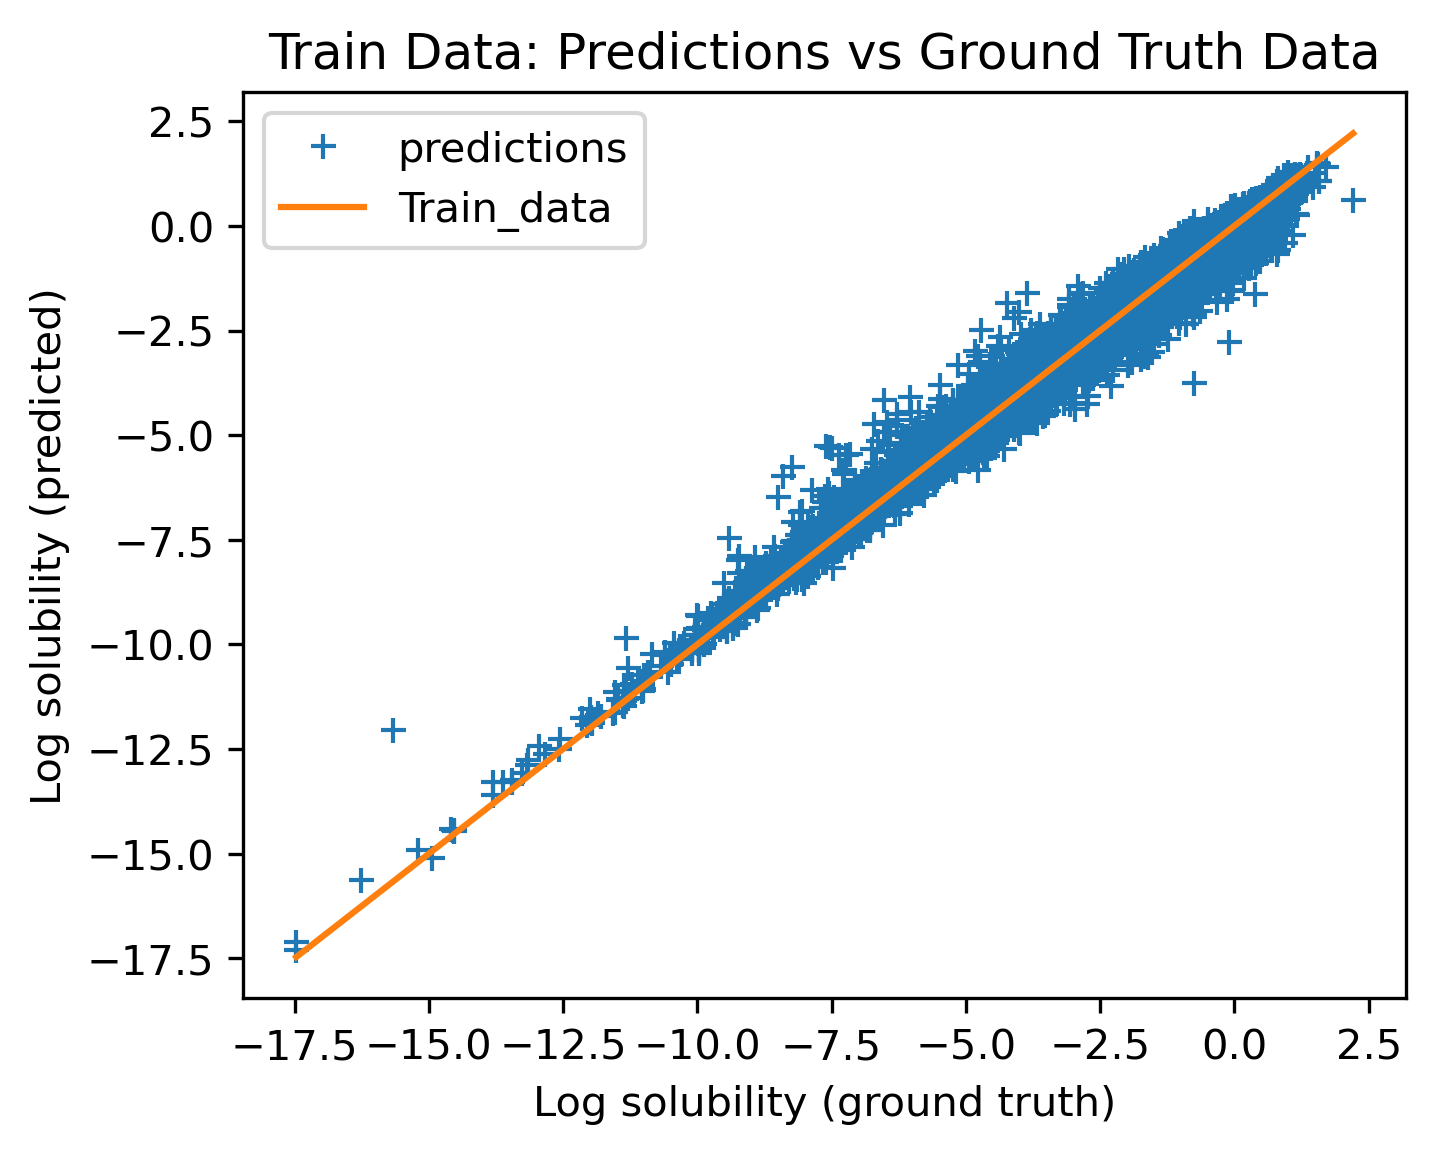

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# Increase figure size and resolution
plt.figure(figsize=(5, 4), dpi=300)

# Your existing plot code
preds = loaded_model.predict(X_train)
x_y_line = np.linspace(min(y_train), max(y_train), 500)
plt.plot(y_train, preds, '+', label='predictions')
plt.plot(x_y_line, x_y_line, label='Train_data')

# Add labels, title, and legend
plt.xlabel("Log solubility (ground truth)")
plt.ylabel("Log solubility (predicted)")
plt.title("Train Data: Predictions vs Ground Truth Data")
plt.legend()

# Display the plot
plt.show()

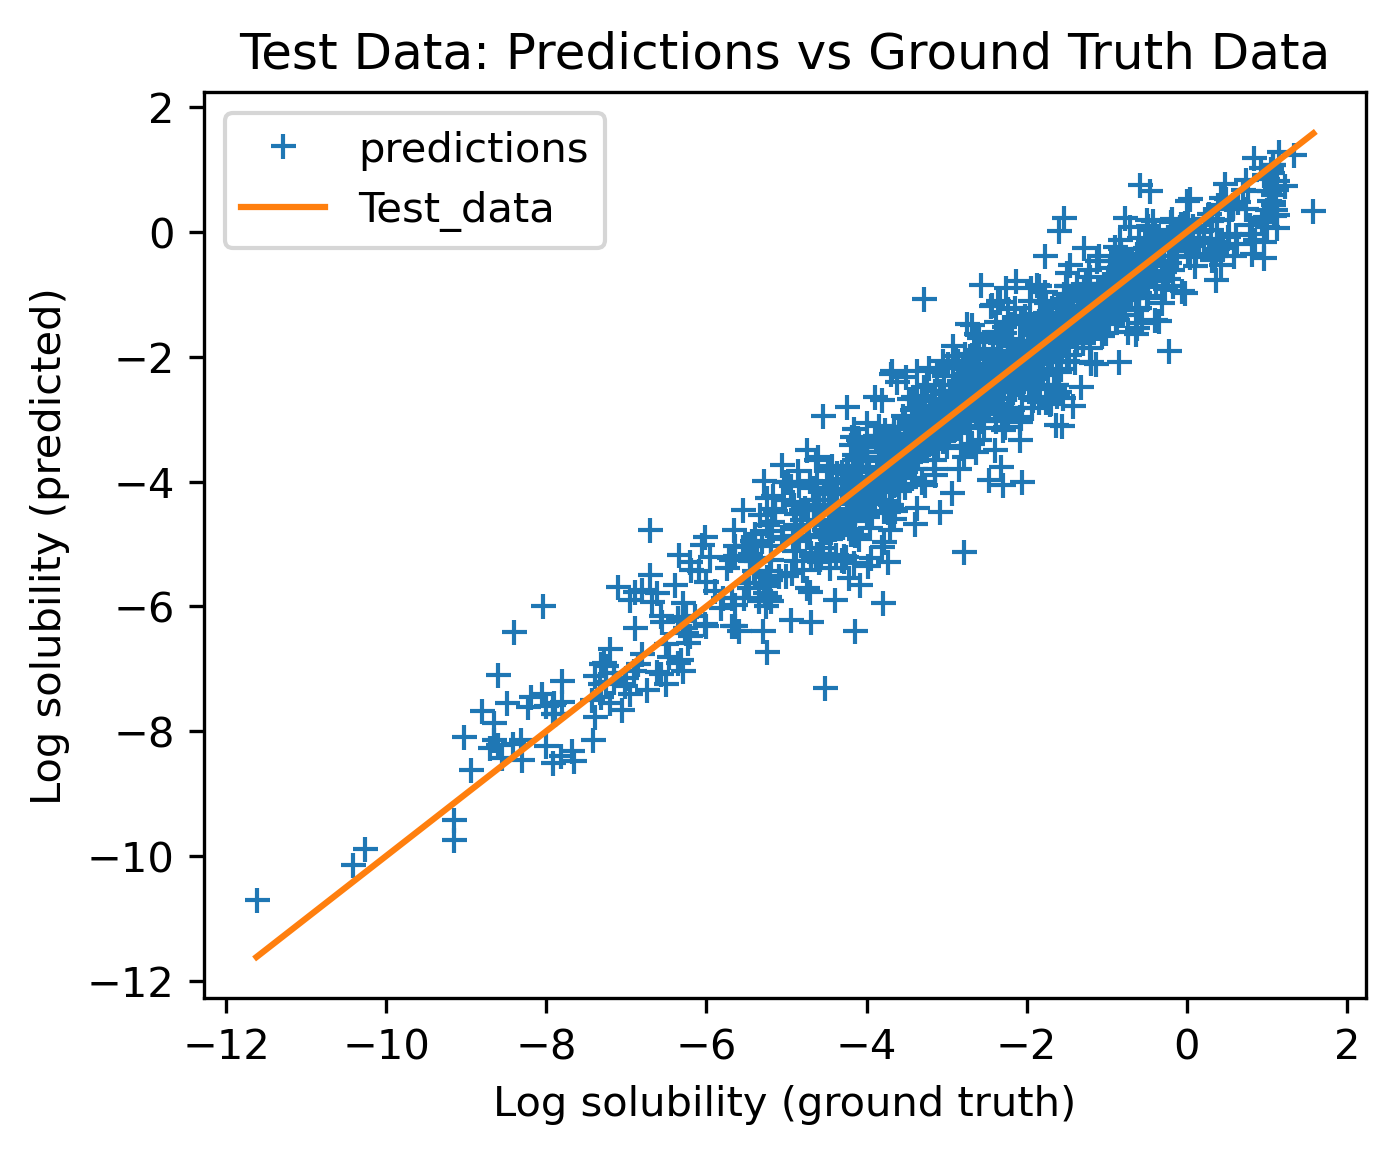

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Increase figure size and resolution
plt.figure(figsize=(5, 4), dpi=300)

# Your existing plot code
preds = loaded_model.predict(X_test)
x_y_line = np.linspace(min(y_test), max(y_test), 500)
plt.plot(y_test, preds, '+', label='predictions')
plt.plot(x_y_line, x_y_line, label='Test_data')

# Add labels, title, and legend
plt.xlabel("Log solubility (ground truth)")
plt.ylabel("Log solubility (predicted)")
plt.title("Test Data: Predictions vs Ground Truth Data")
plt.legend()

# Display the plot
plt.show()

In [ ]:
#### END HERE ....

In [ ]:
#### Comparing the online predictor tool chembcpp...with our prediction

In [124]:
### Taking our test data 1282 
test_set=pd.read_csv('data/unique_test_new24.csv')

In [125]:
### dropping the index number 967 and 968 to match the data as we did not get solubility 
# for these compound from chembcpp.. for some reason as with these smiles can not processed 
test_set = test_set.drop([967, 968])


In [126]:
test_set=test_set.reset_index(drop=True)

In [127]:
test_set

,Unnamed: 0,smiles_canon,Solubility,occurence
0,0,CCCCC,-3.180,1.0
1,1,C1CCCC1,-2.640,1.0
2,2,CCCCCC,-3.840,1.0
3,3,CCCC(C)C,-3.740,1.0
4,4,CCC(C)(C)C,-3.550,1.0
...,...,...,...,...
1275,1277,CCC(C)(O)C(C)C,-1.035,2.0
1276,1278,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,-2.930,2.0
1277,1279,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,-2.015,2.0
1278,1280,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,-6.235,2.0


In [128]:
### making smiles of the test dataset to list 
smiles_list = test_set['smiles_canon'].tolist()


In [129]:

#### Now making our test dataset to sdf file and chembccp takes only sdf file to give the solubility 
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

# Initialize an empty list to hold valid molecule objects
molecules = []

# Iterate over SMILES strings and create molecule objects
for i, smiles in enumerate(smiles_list):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Optionally, generate 3D coordinates
            AllChem.EmbedMolecule(mol)
            # Set a name for the molecule (optional)
            mol.SetProp("_Name", f"Molecule_{i+1}")
            molecules.append(mol)
        else:
            print(f"Warning: SMILES '{smiles}' at index {i} could not be converted to a molecule.")
    except Exception as e:
        print(f"Error processing SMILES '{smiles}' at index {i}: {e}")

# Write valid molecules to an SDF file
if molecules:
    with Chem.SDWriter('data/molecules_test_968_969.sdf') as writer:
        for mol in molecules:
            writer.write(mol)
    print("Molecular file 'molecules_test.sdf' created successfully.")
else:
    print("No valid molecules were found to write to the SDF file.")


Molecular file 'molecules_test.sdf' created successfully.


In [130]:
### Taking out the training dataset of  the chembcpp model 
from rdkit import Chem

# Replace 'example.sdf' with your SDF file path
sdf_file = '/Users/mushtaqali/Desktop/sol_chembcpp/WS_training.sdf'


# Reading the SDF file
suppl = Chem.SDMolSupplier(sdf_file)
SMILES=[]
# Iterate through molecules in the SDF file
for mol in suppl:
    if mol is None:
        continue  # skip molecules that couldn't be parsed
    smiles=Chem.MolToSmiles(mol)  # Print SMILES representation of the molecule
    SMILES.append(smiles)#print(mol.GetNumAtoms())  

In [131]:
# Checking what are the properties this sdf file has 
properties = mol.GetPropsAsDict()
print(properties)    
if 'LogS' in properties:
        print(f"LogS: {properties['LogS']}")
else:
        print("LogS value not found for this molecule.")


{'Name': 'Ethyl 2-formamido-(furan-3-yl)acrylate', 'Source': 'Smiles', 'Tox': 2.748, 'CAS': '336111-18-3'}
LogS value not found for this molecule.


In [132]:
import pandas as pd 
df_smiles = pd.DataFrame(SMILES, columns=['SMILES'])


In [133]:
df_smiles

,SMILES
0,CC(=O)OCC(=O)[C@@]1(O)CCC2C3CCC4=CC(=O)CC[C@]4...
1,CC(=O)OCC(=O)[C@@]1(O)CCC2C3CCC4=CC(=O)CC[C@]4...
2,CCC1(c2ccccc2)C(=O)NC(=O)NC1=O
3,CCC1(CC)C(=O)NC(=O)N(C)C1=O
4,O=P1(N(CCCl)CCCl)NCCCO1
...,...
4011,Fc1cccc(F)c1-c1nnc(-c2ccccc2Cl)nn1
4012,Clc1ccc(Cl)c(Oc2ccccc2)c1Cl
4013,COc1cc(OC)nc(Oc2cccc(Oc3nc(OC)cc(OC)n3)c2C(=O)...
4014,CCOC(=O)/C(=C/c1ccccc1Cl)NC=O


In [134]:
### Finction to create canonical smiles ...
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi
## Function to create canonical smiles 
def canon(smi):
    try:
        mol=smi2mol(smi, sanitize=True)
        smi_canon=mol2smi(mol, isomericSmiles=False, canonical=True)
        return(smi_canon)
    except:
        print("ERROR")
        return(smi)


In [135]:
### train data with chembcpp model get trained
df_smiles['smiles_canon'] = [canon(smi) for smi in df_smiles.SMILES]

In [139]:
#### Find the mathcing smiles in train and test dataset 
matching_smiles = pd.merge(df_smiles[['smiles_canon']], test_set[['smiles_canon']], on='smiles_canon')['smiles_canon']

# Remove the matching SMILES from test dataset 
df_chem_filtered1 = test_set[~test_set['smiles_canon'].isin(matching_smiles)]

In [141]:
df_chem_filtered1.reset_index(drop=True)

,Unnamed: 0,smiles_canon,Solubility,occurence
0,0,CCCCC,-3.18,1.0
1,7,CCCCCCC,-4.53,1.0
2,15,C=CCC(C)C,-3.24,1.0
3,19,C=CCCCCCCC,-5.05,1.0
4,30,Cc1ccccc1,-2.21,1.0
...,...,...,...,...
379,1258,CCNc1nc(Cl)nc(NC(C)C)n1,-3.85,1.0
380,1265,CCOP(=S)(OCC)Oc1ccc([N+](=O)[O-])cc1,-4.66,1.0
381,1267,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,-2.90,1.0
382,1268,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,-3.37,1.0


In [142]:
df_chem_filtered1.to_csv('data/df_chem.csv')

In [144]:
df_chem=pd.read_csv('data/chembcpp_test.csv')

In [153]:
df_chem_filtered1

,Unnamed: 0,smiles_canon,Solubility,occurence
0,0,CCCCC,-3.18,1.0
7,7,CCCCCCC,-4.53,1.0
15,15,C=CCC(C)C,-3.24,1.0
19,19,C=CCCCCCCC,-5.05,1.0
30,30,Cc1ccccc1,-2.21,1.0
...,...,...,...,...
1256,1258,CCNc1nc(Cl)nc(NC(C)C)n1,-3.85,1.0
1263,1265,CCOP(=S)(OCC)Oc1ccc([N+](=O)[O-])cc1,-4.66,1.0
1265,1267,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,-2.90,1.0
1266,1268,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,-3.37,1.0


In [152]:
df_chem

,Unnamed: 0,SMILES,Solubility,mol/L,LogS_chembcpp,Lit_Sol_LogS,MW,XGB_298_LogS
0,0,CCCCC,3.073,0.000845,-3.073,-3.180,72.151,-2.803066
1,1,C1CCCC1,2.572,0.002679,-2.572,-2.640,70.135,-2.857886
2,2,CCCCCC,3.617,0.000242,-3.617,-3.840,86.178,-3.421578
3,3,CCCC(C)C,3.569,0.000270,-3.569,-3.740,86.178,-3.327632
4,4,CCC(C)(C)C,3.508,0.000310,-3.508,-3.550,86.178,-3.451000
...,...,...,...,...,...,...,...,...
1275,1275,CCC(C)(O)C(C)C,0.932,0.116950,-0.932,-1.035,116.204,-1.055869
1276,1276,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,3.136,0.000731,-3.136,-2.930,279.340,-3.156507
1277,1277,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,2.109,0.007780,-2.109,-2.015,289.375,-2.326054
1278,1278,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC54)C3C1(Cl)C2(Cl)Cl,5.905,0.000001,-5.905,-6.235,380.913,-6.539933


In [155]:
df_chem['smiles_canon']= [canon(smi) for smi in df_chem.SMILES]

In [158]:
matching_smiles = pd.merge(df_chem_filtered1[['smiles_canon']], df_chem[['smiles_canon']], on='smiles_canon')['smiles_canon']

# Remove the matching SMILES from test dataset 
df_smiles_new = df_chem[df_chem['smiles_canon'].isin(matching_smiles)]

In [159]:
df_smiles_new

,Unnamed: 0,SMILES,Solubility,mol/L,LogS_chembcpp,Lit_Sol_LogS,MW,XGB_298_LogS,smiles_canon
0,0,CCCCC,3.073,0.000845,-3.073,-3.18,72.151,-2.803066,CCCCC
7,7,CCCCCCC,4.263,0.000055,-4.263,-4.53,100.205,-4.019503,CCCCCCC
15,15,C=CCC(C)C,2.960,0.001096,-2.960,-3.24,84.162,-2.894220,C=CCC(C)C
19,19,C=CCCCCCCC,4.885,0.000013,-4.885,-5.05,126.243,-4.236306,C=CCCCCCCC
30,30,Cc1ccccc1,2.134,0.007345,-2.134,-2.21,92.141,-2.423916,Cc1ccccc1
...,...,...,...,...,...,...,...,...,...
1256,1256,CCNc1nc(Cl)nc(NC(C)C)n1,3.506,0.000312,-3.506,-3.85,215.688,-3.083904,CCNc1nc(Cl)nc(NC(C)C)n1
1263,1263,CCOP(=S)(OCC)Oc1ccc([N+](=O)[O-])cc1,4.165,0.000068,-4.165,-4.66,291.265,-4.259642,CCOP(=S)(OCC)Oc1ccc([N+](=O)[O-])cc1
1265,1265,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,4.561,0.000027,-4.561,-2.90,318.328,-3.681481,O=C1OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21
1266,1266,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,2.820,0.001514,-2.820,-3.37,330.364,-2.499015,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC


In [161]:
chembcpp=utilities.get_errors1(df_smiles_new['Lit_Sol_LogS'],df_smiles_new['LogS_chembcpp'],"ChemBCPP")
xgb_298=utilities.get_errors1(df_smiles_new['Lit_Sol_LogS'],df_smiles_new['XGB_298_LogS'],"XGB_298")

In [197]:
y_test=test_set.Solubility

In [162]:
chembcpp

,Model_Name,MAE,MSE,RMSE,R2
0,ChemBCPP,0.3753,0.2962,0.5442,0.927


In [163]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_298,0.4562,0.3675,0.6062,0.9095


In [166]:
### Generate 125 feature engineered based on the structure of the smiles ....
df125_test=utilities.generate123(df_smiles_new.smiles_canon)
df125_train=utilities.generate123(train_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....

In [170]:
df17_test=utilities.generate17(df_smiles_new.smiles_canon)
df17_train=utilities.generate17(train_set.smiles_canon)

In [167]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
                                           
## Fitting the model on train data 
xgboost_model.fit(df125_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df125_test)
### Calculating the evaluation matrix MAE , RMSE and R2
df_smiles_new['XGB_125_LogS']=pred_xgb

In [168]:
xgb_125=utilities.get_errors1(df_smiles_new['Lit_Sol_LogS'],df_smiles_new['XGB_125_LogS'],"XGB_125")

In [169]:
xgb_125

,Model_Name,MAE,MSE,RMSE,R2
0,XGB_125,0.4352,0.3527,0.5939,0.9131


In [182]:
df_train2 = pd.concat([df123_train, y_train], axis=1)
df_test2 = pd.concat([df123_test, y_test], axis=1)
df_train = df_train2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
df_test = df_test2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [225]:
### Ensemble model 
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=2000,          # Number of trees
    max_depth=8,              # Maximum depth of each tree
    min_samples_split=2,       # Minimum samples required to split an internal node
    min_samples_leaf=1,        # Minimum samples required to be at a leaf node
    max_features='auto',       # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
rf_model.fit(X_train, y_train)

# xgboost model 
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
xgboost_model.fit(X_train, y_train)

# Gradient Boosting
boosting_model = gb = GradientBoostingRegressor(
    n_estimators=2000,          # Number of boosting stages to be run
    learning_rate=0.01,         # Learning rate shrinks the contribution of each tree
    max_depth=8,               # Maximum depth of the individual estimators
    min_samples_split=2,       # Minimum number of samples required to split an internal node
    min_samples_leaf=1,        # Minimum number of samples required to be at a leaf node
    max_features=None,         # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
boosting_model.fit(X_train, y_train)

# Cubist (This requires external libraries)
# Uncomment if Cubist is available in your environment
# from cubist import Cubist
# cubist_model = Cubist()
# cubist_model.fit(X_train, y_train)

# Step 2: Get predictions from the base models on training and test data

# Train predictions (to stack them)
rf_train_pred = rf_model.predict(X_train)
xgb_train_pred = xgboost_model.predict(X_train)
boosting_train_pred = boosting_model.predict(X_train)
# cubist_train_pred = cubist_model.predict(X_train)  # Uncomment if using Cubist

# Test predictions (for final evaluation after stacking)
rf_test_pred = rf_model.predict(X_test)
xgb_test_pred = xgboost_model.predict(X_test)
boosting_test_pred = boosting_model.predict(X_test)
# cubist_test_pred = cubist_model.predict(X_test)  # Uncomment if using Cubist

# Step 3: Stack the predictions together for training the meta-model
stacked_train_predictions = np.column_stack((rf_train_pred, xgb_train_pred, boosting_train_pred))  # Add cubist_train_pred if using Cubist
stacked_test_predictions = np.column_stack((rf_test_pred, xgb_test_pred, boosting_test_pred))  # Add cubist_test_pred if using Cubist

# Step 4: Train a meta-model on the stacked predictions
meta_model = xgboost()  # You can use any regressor here
meta_model.fit(stacked_train_predictions, y_train)

# Step 5: Make final predictions using the meta-model on the test data
final_test_prediction = meta_model.predict(stacked_test_predictions)

# Step 6: Evaluate the performance of the ensemble model
mae = mean_absolute_error(y_test, final_test_prediction)
print(f'Ensemble Test MAE: {mae}')


TypeError: 'module' object is not callable

In [218]:
### Making the prediction shape unified..
if len(pred_nn.shape) > 1 and pred_nn.shape[1] == 1:
    pred_nn = pred_nn.flatten()  # Convert (n_samples, 1) to (n_samples,)


In [220]:
pred_gb.shape

(1282,)

In [224]:
# Neural Network prediction
#nn_predictions = embedding_model.predict([X_smiles_test, X_properties_test])

# Combine Neural Network and Traditional Model predictions (averaging or weighted sum)
final_predictions = (0.5*pred_xgb)+(0.5*pred_gb)

# Evaluate the final blended model
mae_blended = mean_absolute_error(y_test, final_predictions)
print(f'Blended Model Test MAE: {mae_blended}')


Blended Model Test MAE: 0.40948047087958284


In [ ]:
### End here ...